# Assignment 1 (MSDM5053)
- Author: LAN, Tianwei <br>
- Email: tlanaa@connect.ust.hk <br>

## Datasets & Packages

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use("seaborn-v0_8")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", "{:.4f}".format)

In [7]:
# Load all datasets once
md = pd.read_csv("m-dec19.txt", sep=r"\s+")
dec1 = md["dec1"]
dec9 = md["dec9"]

cpi = pd.read_csv("m-cpileng.txt", sep=r"\s+", header=None, names=["year", "mm", "dd", "cpi"])
ct = 100 * np.log(cpi["cpi"]).diff().dropna()
zt = ct.diff().dropna()

gnp = pd.read_csv("q-gnprate.txt", header=None, names=["rate"])["rate"]


def acf_table(x, nlags):
    values = acf(x, nlags=nlags, fft=False)[1:]
    return pd.DataFrame({"lag": np.arange(1, nlags + 1), "acf": values})


def pacf_table(x, nlags):
    values = pacf(x, nlags=nlags, method="ywm")[1:]
    return pd.DataFrame({"lag": np.arange(1, nlags + 1), "pacf": values})

## Question 1: Decile 1 monthly returns

Q1(a) ACF and PACF (first 24 lags)
 lag     acf    pacf
   1  0.2246  0.2246
   2 -0.0022 -0.0554
   3 -0.0762 -0.0668
   4 -0.0297  0.0032
   5 -0.0224 -0.0205
   6 -0.0507 -0.0502
   7 -0.0504 -0.0318
   8 -0.0849 -0.0752
   9 -0.0792 -0.0565
  10 -0.0045  0.0164
  11  0.0757  0.0604
  12  0.2675  0.2396
  13  0.0177 -0.1062
  14 -0.0516 -0.0291
  15 -0.0922 -0.0570
  16 -0.0244 -0.0037
  17 -0.0417 -0.0473
  18 -0.0911 -0.0697
  19 -0.0802 -0.0353
  20 -0.0509 -0.0011
  21 -0.0576 -0.0481
  22 -0.0487 -0.0614
  23  0.0526  0.0373
  24  0.2473  0.1678


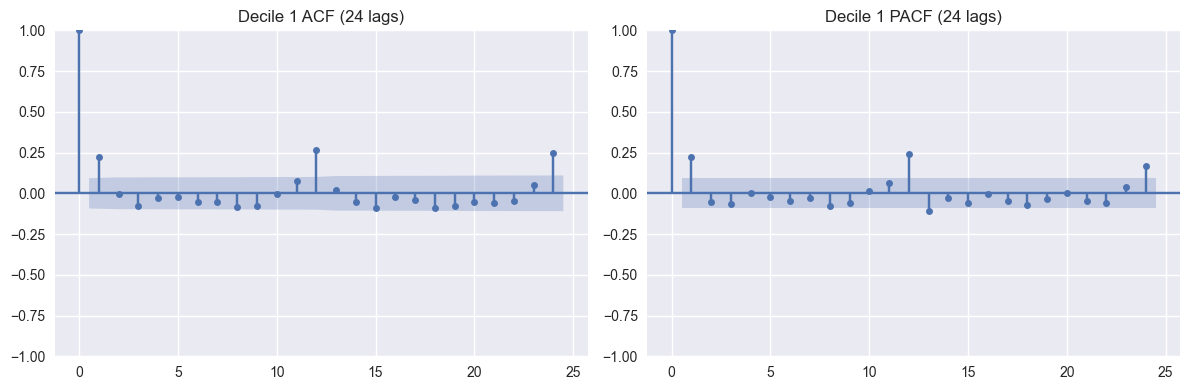

Q1(b) Ljung-Box Q(12) = 69.6524, p-value = 3.72e-10


In [12]:
# Q1(a): first 24 lags of ACF and PACF
q1_acf24 = acf_table(dec1, 24)
q1_pacf24 = pacf_table(dec1, 24)
q1_ap24 = pd.DataFrame({
    "lag": q1_acf24["lag"],
    "acf": q1_acf24["acf"],
    "pacf": q1_pacf24["pacf"]
})

print("Q1(a) ACF and PACF (first 24 lags)")
print(q1_ap24.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(dec1, lags=24, ax=axes[0])
axes[0].set_title("Decile 1 ACF (24 lags)")
plot_pacf(dec1, lags=24, method="ywm", ax=axes[1])
axes[1].set_title("Decile 1 PACF (24 lags)")
plt.tight_layout()
plt.show()

# Q1(b): test H0: rho_1 = ... = rho_12 = 0
q1_lb12 = acorr_ljungbox(dec1, lags=[12], return_df=True)
q1_stat = q1_lb12.loc[12, "lb_stat"]
q1_p = q1_lb12.loc[12, "lb_pvalue"]
print(f"Q1(b) Ljung-Box Q(12) = {q1_stat:.4f}, p-value = {q1_p:.4g}")

- Q1(b): reject $H_0$. At least one of the first 12 ACFs is nonzero.

## Question 2: Decile 9 monthly returns

Q2(a) ACF (first 12 lags)
 lag     acf
   1  0.1367
   2 -0.0624
   3 -0.0334
   4 -0.0591
   5 -0.0091
   6  0.0028
   7 -0.0111
   8 -0.0782
   9 -0.0271
  10  0.0430
  11 -0.0356
  12  0.0053


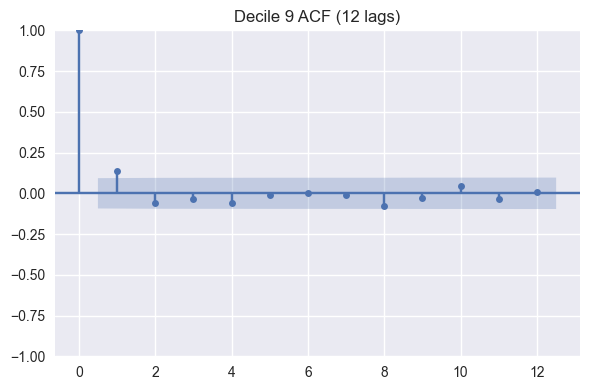

Q2(b) Ljung-Box Q(12) = 16.8115, p-value = 0.1568


In [21]:
# Q2(a): first 12 lags of ACF
q2_acf12 = acf_table(dec9, 12)
print("Q2(a) ACF (first 12 lags)")
print(q2_acf12.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
plot_acf(dec9, lags=12, ax=ax)
ax.set_title("Decile 9 ACF (12 lags)")
plt.tight_layout()
plt.show()

# Q2(b): test H0: rho_1 = ... = rho_12 = 0
q2_lb12 = acorr_ljungbox(dec9, lags=[12], return_df=True)
q2_stat = q2_lb12.loc[12, "lb_stat"]
q2_p = q2_lb12.loc[12, "lb_pvalue"]
print(f"Q2(b) Ljung-Box Q(12) = {q2_stat:.4f}, p-value = {q2_p:.4g}")

- Q2(b): fail to reject $H_0$. The first 12 ACFs are jointly insignificant.

## Question 3: CPI less energy

Q3(a) ACF and PACF of c_t (12 lags)
 lag    acf    pacf
   1 0.5834  0.5834
   2 0.5964  0.3881
   3 0.5579  0.2117
   4 0.5008  0.0702
   5 0.5663  0.2221
   6 0.5515  0.1592
   7 0.5299  0.0699
   8 0.5555  0.1176
   9 0.5458  0.1139
  10 0.5636  0.1212
  11 0.4976 -0.0483
  12 0.5030  0.0122


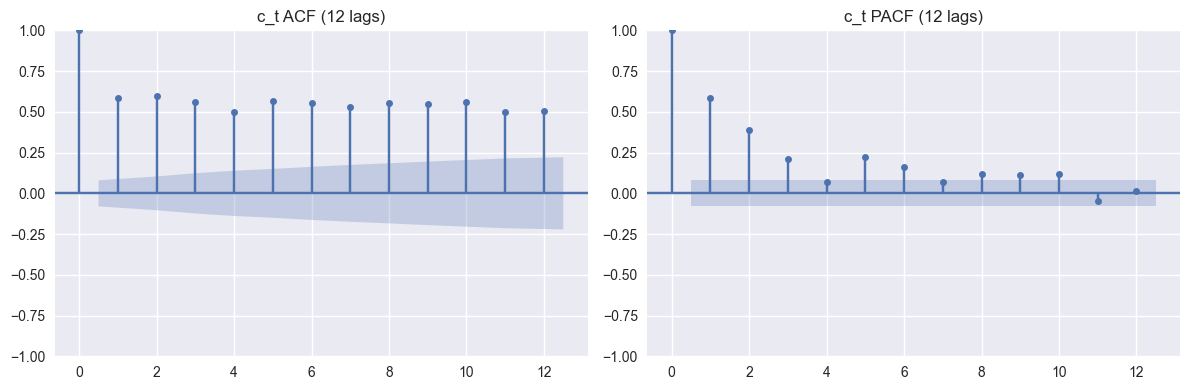

Q3(a) Ljung-Box Q(12) = 2186.6458, p-value = 0
Q3(b) ACF of z_t (12 lags)
 lag     acf
   1 -0.5155
   2  0.0618
   3  0.0222
   4 -0.1472
   5  0.0962
   6  0.0084
   7 -0.0564
   8  0.0423
   9 -0.0331
  10  0.1005
  11 -0.0856
  12  0.0417


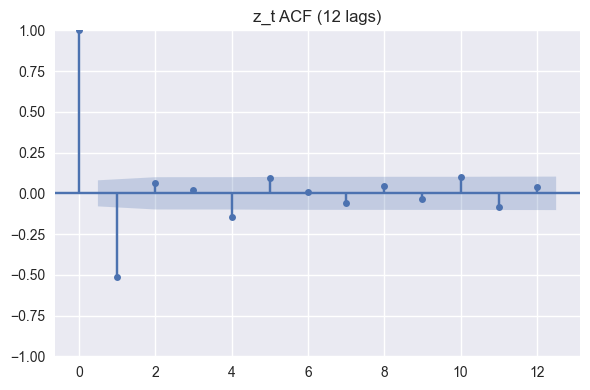

Q3(c) ARMA(1,5) parameter estimates
const     0.3234
ar.L1     0.9782
ma.L1    -0.8160
ma.L2     0.0652
ma.L3    -0.0997
ma.L4    -0.1061
ma.L5     0.1913
sigma2    0.0339
dtype: float64


In [28]:
# Q3(a): ACF/PACF (12 lags) and Ljung-Box test
q3_acf12 = acf_table(ct, 12)
q3_pacf12 = pacf_table(ct, 12)
q3_ap12 = pd.DataFrame({
    "lag": q3_acf12["lag"],
    "acf": q3_acf12["acf"],
    "pacf": q3_pacf12["pacf"]
})

print("Q3(a) ACF and PACF of c_t (12 lags)")
print(q3_ap12.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ct, lags=12, ax=axes[0])
axes[0].set_title("c_t ACF (12 lags)")
plot_pacf(ct, lags=12, method="ywm", ax=axes[1])
axes[1].set_title("c_t PACF (12 lags)")
plt.tight_layout()
plt.show()

q3_lb12 = acorr_ljungbox(ct, lags=[12], return_df=True)
q3_stat = q3_lb12.loc[12, "lb_stat"]
q3_p = q3_lb12.loc[12, "lb_pvalue"]
print(f"Q3(a) Ljung-Box Q(12) = {q3_stat:.4f}, p-value = {q3_p:.4g}")

# Q3(b): ACF of differenced series z_t = c_t - c_{t-1}
q3_zacf12 = acf_table(zt, 12)
print("Q3(b) ACF of z_t (12 lags)")
print(q3_zacf12.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
plot_acf(zt, lags=12, ax=ax)
ax.set_title("z_t ACF (12 lags)")
plt.tight_layout()
plt.show()

# Q3(c): fit ARMA(1,5) to c_t
q3_arma15 = ARIMA(ct, order=(1, 0, 5), trend="c").fit()
p = q3_arma15.params
print("Q3(c) ARMA(1,5) parameter estimates")
print(p)

### Conclusion (Q3)

- Q3(a): reject $H_0$. The first 12 ACFs are not jointly zero.
- Q3(c) fitted model:

$$
c_t = 0.323 + 0.978c_{t-1} + a_t - 0.816a_{t-1} + 0.065a_{t-2} - 0.100a_{t-3} - 0.106a_{t-4} + 0.191a_{t-5}
$$

## Question 4: U.S. real GNP growth rate

In [44]:
# Q4(a): fit AR(3)
q4_ar3 = ARIMA(gnp, order=(3, 0, 0), trend="c").fit()
q4_p = q4_ar3.params
print("Q4(a) AR(3) parameter estimates")
print(q4_p)
print("")

# Q4(b): business-cycle period from complex roots (if they exist)
phi = q4_ar3.arparams
roots = np.roots(np.r_[1, -phi])
complex_roots = [r for r in roots if abs(np.imag(r)) > 1e-8]
if complex_roots:
    periods = [2 * np.pi / abs(np.angle(r)) for r in complex_roots]
    avg_period = float(np.mean(periods))
    print(f"Q4(b) Average cycle period (quarters): {avg_period:.4f}")
else:
    print("Q4(b) No complex roots.")
print("")

# Q4(c): 1- to 4-step forecasts at the end of sample
q4_fc = q4_ar3.get_forecast(steps=4)
q4_forecast = pd.DataFrame({
    "horizon": np.arange(1, 5),
    "forecast": q4_fc.predicted_mean.values,
    "std_error": np.sqrt(q4_fc.var_pred_mean.values)
})
print("Q4(c) Forecasts and standard errors")
print(q4_forecast.to_string(index=False))

Q4(a) AR(3) parameter estimates
const     0.0168
ar.L1     0.4171
ar.L2     0.2002
ar.L3    -0.1648
sigma2    0.0001
dtype: float64

Q4(b) Average cycle period (quarters): 11.5944

Q4(c) Forecasts and standard errors
 horizon  forecast  std_error
       1    0.0140     0.0096
       2    0.0161     0.0105
       3    0.0167     0.0111
       4    0.0171     0.0111


- Q4(a) fitted model:

$$
x_t = 0.017 + 0.417x_{t-1} + 0.200x_{t-2} - 0.165x_{t-3} + a_t
$$

- Q4(b): business cycle exists, average period is about $11.5944$ quarters.

## Question 5: MA(1) for Decile 9 returns

In [43]:
# Q5(a): fit MA(1)
q5_ma1 = ARIMA(dec9, order=(0, 0, 1), trend="c").fit()
q5_p = q5_ma1.params
print("Q5(a) MA(1) parameter estimates")
print(q5_p)
print("")

# Q5(b): adequacy check by Ljung-Box test on residuals
q5_lb_resid = acorr_ljungbox(q5_ma1.resid, lags=[12], return_df=True)
q5_stat = q5_lb_resid.loc[12, "lb_stat"]
q5_pv = q5_lb_resid.loc[12, "lb_pvalue"]
print(f"Q5(b) Residual Ljung-Box Q(12) = {q5_stat:.4f}, p-value = {q5_pv:.4g}")
print("")

# Q5(c): 1- to 4-step forecasts using the last observation as origin
q5_fc = q5_ma1.get_forecast(steps=4)
q5_forecast = pd.DataFrame({
    "horizon": np.arange(1, 5),
    "forecast": q5_fc.predicted_mean.values,
    "std_error": np.sqrt(q5_fc.var_pred_mean.values)
})
print("Q5(c) Forecasts and standard errors")
print(q5_forecast.to_string(index=False))

Q5(a) MA(1) parameter estimates
const    0.0109
ma.L1    0.1593
sigma2   0.0027
dtype: float64

Q5(b) Residual Ljung-Box Q(12) = 8.2192, p-value = 0.7678

Q5(c) Forecasts and standard errors
 horizon  forecast  std_error
       1    0.0090     0.0520
       2    0.0109     0.0526
       3    0.0109     0.0526
       4    0.0109     0.0526


- Q5(a) fitted model:

$$
x_t = 0.011 + a_t + 0.159a_{t-1}
$$

- Q5(b): fail to reject residual autocorrelation null at lag 12, so the MA(1) model is adequate.